In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
# Import the tool used to split data into training and testing sets.
from sklearn.model_selection import train_test_split
# Import the preprocessing tools needed for machine learning.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# Import Pipeline to connect preprocessing and the model.
from sklearn.pipeline import Pipeline
# Import Logistic Regression, our first classification model.
from sklearn.linear_model import LogisticRegression



In [2]:
# ACQUIRE: Read the supplied file and verify the structure.
df = pd.read_csv("downloads/heart disease.csv")
print("Dataset shape:", df.shape)
print(df.head())
df.info()
print(df.describe())

Dataset shape: (918, 12)
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  ----- 

In [3]:
# Review all categorical levels and validate expected binary encodings.
for column in ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope", "FastingBS", "HeartDisease"]:
    print(f"\n{column} levels:\n", df[column].value_counts(dropna=False))
for column in ["FastingBS", "HeartDisease"]:
    print(column, "contains only 0 and 1:", bool(np.isin(df[column].to_numpy(), [0, 1]).all()))


Sex levels:
 Sex
M    725
F    193
Name: count, dtype: int64

ChestPainType levels:
 ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

RestingECG levels:
 RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

ExerciseAngina levels:
 ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

ST_Slope levels:
 ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

FastingBS levels:
 FastingBS
0    704
1    214
Name: count, dtype: int64

HeartDisease levels:
 HeartDisease
1    508
0    410
Name: count, dtype: int64
FastingBS contains only 0 and 1: True
HeartDisease contains only 0 and 1: True


In [4]:
# Investigate possible coded missing values; retain originals and flag them.
prepared_df = df.copy()
prepared_df["RestingBP_zero_flag"] = prepared_df["RestingBP"].eq(0)
prepared_df["Cholesterol_zero_flag"] = prepared_df["Cholesterol"].eq(0)
prepared_df["Oldpeak_negative_flag"] = prepared_df["Oldpeak"].lt(0)
for flag in ["RestingBP_zero_flag", "Cholesterol_zero_flag", "Oldpeak_negative_flag"]:
    print(flag, int(np.sum(prepared_df[flag].to_numpy())))

RestingBP_zero_flag 1
Cholesterol_zero_flag 172
Oldpeak_negative_flag 13


In [5]:
# Summarize class balance and calculate percentages.
target_counts = prepared_df["HeartDisease"].value_counts().sort_index()
print(pd.DataFrame({"Count": target_counts, "Percent": (100 * target_counts / len(prepared_df)).round(1)}))

              Count  Percent
HeartDisease                
0               410     44.7
1               508     55.3


In [6]:
# IQR screening flags potential outliers, not necessarily errors.
cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
data = prepared_df[cols]

q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
iqr = q3 - q1

outlier_counts = ((data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)).sum()

print("IQR potential outliers per column:")
print(outlier_counts.to_string())

IQR potential outliers per column:
Age              0
RestingBP       28
Cholesterol    183
MaxHR            2
Oldpeak         16


In [7]:
# ANALYZE: Outcome proportions within categories (not raw counts alone).
cat_cols = ["ChestPainType", "ExerciseAngina", "ST_Slope", "Sex"]

long_df = prepared_df.melt(
    id_vars="HeartDisease",
    value_vars=cat_cols,
    var_name="feature",
    value_name="category",
)

summary = long_df.groupby(["feature", "category"])["HeartDisease"].agg(
    n="size", outcome_rate="mean"
)
summary["outcome_rate"] = (summary["outcome_rate"] * 100).round(1)

print("Outcome percentage by category:\n", summary)
print("\nMedian numerical values by outcome:\n",
      prepared_df.groupby("HeartDisease")[["Age", "MaxHR", "Oldpeak"]].median())

Outcome percentage by category:
                            n  outcome_rate
feature        category                   
ChestPainType  ASY       496          79.0
               ATA       173          13.9
               NAP       203          35.5
               TA         46          43.5
ExerciseAngina N         547          35.1
               Y         371          85.2
ST_Slope       Down       63          77.8
               Flat      460          82.8
               Up        395          19.7
Sex            F         193          25.9
               M         725          63.2

Median numerical values by outcome:
                Age  MaxHR  Oldpeak
HeartDisease                      
0             51.0  150.0      0.0
1             57.0  126.0      1.2


In [8]:
# ============================================================
# MICRO-PROJECT 3: PREPARE DATA FOR MACHINE LEARNING
# ============================================================

# X contains the predictor variables used to predict heart disease.
# We remove HeartDisease because that is the answer we want to predict.
# We also remove the three flag columns that were created during
# data exploration in Micro-Project 2.

X = prepared_df.drop(
    columns=[
        "HeartDisease",
        "RestingBP_zero_flag",
        "Cholesterol_zero_flag",
        "Oldpeak_negative_flag"
    ]
)

# y contains the target variable.
# 0 = no reported heart disease
# 1 = reported heart disease
y = prepared_df["HeartDisease"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (918, 11)
y shape: (918,)


In [9]:
# Split the dataset into training and testing sets.
# 80% of the data will be used to train the model.
# 20% will be kept separate to test the model.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the number of records in each set.
print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 734
Testing records: 184


In [10]:
# Identify categorical and numerical predictor variables.
# The machine-learning models need these two types of data
# to be prepared differently.

categorical_features = X.select_dtypes(include=["object", "str"]).columns.tolist()

numerical_features = X.select_dtypes(exclude=["object", "str"]).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

Numerical features:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']


In [11]:

# Create the preprocessing process.
#
# StandardScaler prepares the numerical variables by placing
# them on comparable scales.
#
# OneHotEncoder converts categorical variables such as
# Sex, ChestPainType, and ST_Slope into numerical values.

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [12]:

# Create the Logistic Regression pipeline.
# Step 1: Preprocess the numerical and categorical variables.
# Step 2: Use Logistic Regression for classification.

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

print("Logistic Regression pipeline created successfully.")

Logistic Regression pipeline created successfully.


In [13]:
# Train the Logistic Regression model using the training data.
# X_train contains the patient characteristics.
# y_train contains the known HeartDisease outcomes.

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [14]:
# Use the trained Logistic Regression model to predict
# HeartDisease for the 184 test records.

logistic_predictions = logistic_model.predict(X_test)

print("Number of predictions:", len(logistic_predictions))

# Display the first 10 predictions.
print("First 10 predictions:")
print(logistic_predictions[:10])

Number of predictions: 184
First 10 predictions:
[1 0 1 1 0 0 0 1 0 1]


In [15]:
# Import classification evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Compare the model's predictions with the actual
# HeartDisease values in the test data.

logistic_accuracy = accuracy_score(y_test, logistic_predictions)
logistic_precision = precision_score(y_test, logistic_predictions)
logistic_recall = recall_score(y_test, logistic_predictions)
logistic_f1 = f1_score(y_test, logistic_predictions)

print("Logistic Regression Results")
print("Accuracy:", round(logistic_accuracy, 3))
print("Precision:", round(logistic_precision, 3))
print("Recall:", round(logistic_recall, 3))
print("F1 Score:", round(logistic_f1, 3))

Logistic Regression Results
Accuracy: 0.886
Precision: 0.872
Recall: 0.931
F1 Score: 0.9


In [16]:
# Import the confusion matrix tool.
from sklearn.metrics import confusion_matrix

# Create the confusion matrix by comparing
# the actual outcomes with the model's predictions.
logistic_cm = confusion_matrix(y_test, logistic_predictions)

print("Logistic Regression Confusion Matrix:")
print(logistic_cm)

Logistic Regression Confusion Matrix:
[[68 14]
 [ 7 95]]


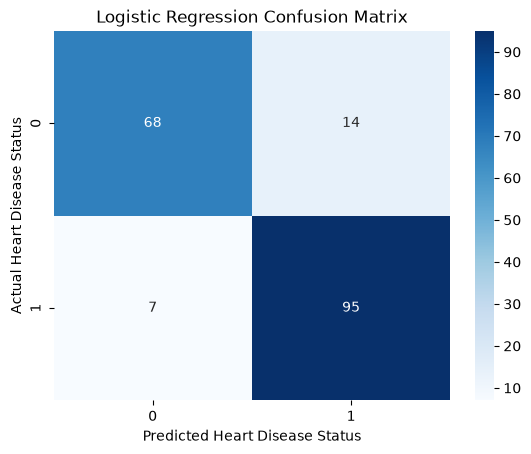

In [17]:
# Display the Logistic Regression confusion matrix as a heatmap.

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Heart Disease Status")
plt.ylabel("Actual Heart Disease Status")

plt.show()

In [18]:
# ============================================================
# MODEL 2: SUPPORT VECTOR MACHINE (SVM)
# ============================================================

# Import the Support Vector Classifier.
from sklearn.svm import SVC

# Create the SVM pipeline.
# The same preprocessing steps are used before training the model.

svm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", SVC(random_state=42))
    ]
)

print("SVM pipeline created successfully.")

SVM pipeline created successfully.


In [19]:
# Train the SVM model using the training data.

svm_model.fit(X_train, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


In [20]:
# Use the trained SVM model to predict
# HeartDisease for the 184 test records.

svm_predictions = svm_model.predict(X_test)

print("Number of predictions:", len(svm_predictions))

print("First 10 predictions:")
print(svm_predictions[:10])

Number of predictions: 184
First 10 predictions:
[1 1 1 1 0 0 0 1 0 1]


In [21]:
# Evaluate the SVM predictions.

svm_accuracy = accuracy_score(y_test, svm_predictions)
svm_precision = precision_score(y_test, svm_predictions)
svm_recall = recall_score(y_test, svm_predictions)
svm_f1 = f1_score(y_test, svm_predictions)

print("SVM Results")
print("Accuracy:", round(svm_accuracy, 3))
print("Precision:", round(svm_precision, 3))
print("Recall:", round(svm_recall, 3))
print("F1 Score:", round(svm_f1, 3))

SVM Results
Accuracy: 0.897
Precision: 0.888
Recall: 0.931
F1 Score: 0.909


In [22]:
# Create the confusion matrix for SVM.

svm_cm = confusion_matrix(y_test, svm_predictions)

print("SVM Confusion Matrix:")
print(svm_cm)

SVM Confusion Matrix:
[[70 12]
 [ 7 95]]


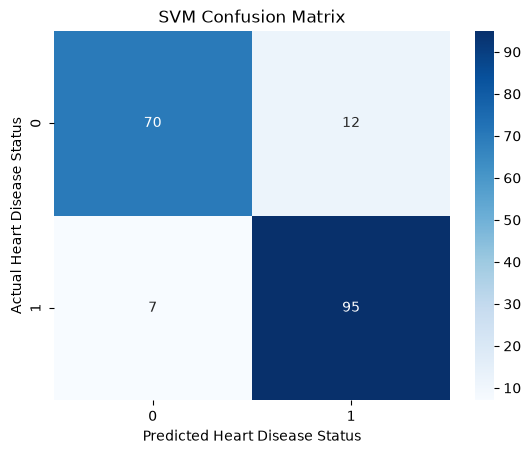

In [23]:
# Display the SVM confusion matrix as a heatmap.

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Heart Disease Status")
plt.ylabel("Actual Heart Disease Status")

plt.show()

In [24]:
# ============================================================
# MODEL 3: RANDOM FOREST CLASSIFIER
# ============================================================

# Import the Random Forest Classifier.
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest pipeline.
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


In [25]:
# Train the Random Forest model using the same training data.

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [26]:
# Use the trained Random Forest model to predict
# HeartDisease for the 184 test records.

random_forest_predictions = random_forest_model.predict(X_test)

print("Number of predictions:", len(random_forest_predictions))

print("First 10 predictions:")
print(random_forest_predictions[:10])

Number of predictions: 184
First 10 predictions:
[1 0 1 1 0 0 0 1 0 1]


In [27]:
# Evaluate the Random Forest predictions.

random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

random_forest_precision = precision_score(
    y_test,
    random_forest_predictions
)

random_forest_recall = recall_score(
    y_test,
    random_forest_predictions
)

random_forest_f1 = f1_score(
    y_test,
    random_forest_predictions
)

print("Random Forest Results")
print("Accuracy:", round(random_forest_accuracy, 3))
print("Precision:", round(random_forest_precision, 3))
print("Recall:", round(random_forest_recall, 3))
print("F1 Score:", round(random_forest_f1, 3))

Random Forest Results
Accuracy: 0.891
Precision: 0.894
Recall: 0.912
F1 Score: 0.903


In [28]:
# Create the confusion matrix for Random Forest.

random_forest_cm = confusion_matrix(
    y_test,
    random_forest_predictions
)

print("Random Forest Confusion Matrix:")
print(random_forest_cm)

Random Forest Confusion Matrix:
[[71 11]
 [ 9 93]]


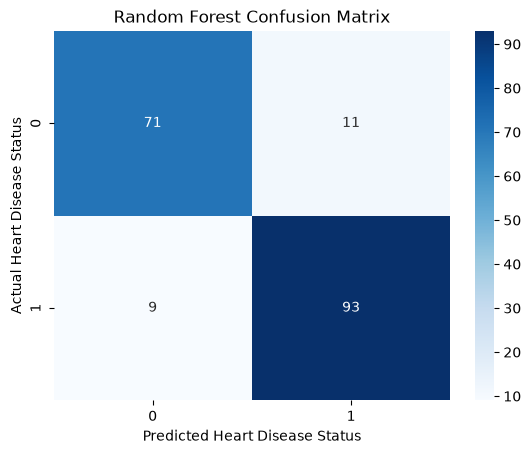

In [29]:
# Display the Random Forest confusion matrix as a heatmap.

sns.heatmap(
    random_forest_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Heart Disease Status")
plt.ylabel("Actual Heart Disease Status")

plt.show()

In [30]:
# ============================================================
# COMPARaison of all 3 mofdels
# ============================================================

# for each machine learning model.

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        svm_accuracy,
        random_forest_accuracy
    ],
    "Precision": [
        logistic_precision,
        svm_precision,
        random_forest_precision
    ],
    "Recall": [
        logistic_recall,
        svm_recall,
        random_forest_recall
    ],
    "F1 Score": [
        logistic_f1,
        svm_f1,
        random_forest_f1
    ]
})

# Round the results to three decimal places.
model_comparison = model_comparison.round(3)

print("Model Comparison:")
# Bold the highest value in each performance metric.

styled_comparison = model_comparison.style.highlight_max(
    subset=["Accuracy", "Precision", "Recall", "F1 Score"],
    props="font-weight: bold;"
)

display(styled_comparison)

Model Comparison:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.886000,0.872000,0.931000,0.900000
1,SVM,0.897000,0.888000,0.931000,0.909000
2,Random Forest,0.891000,0.894000,0.912000,0.903000


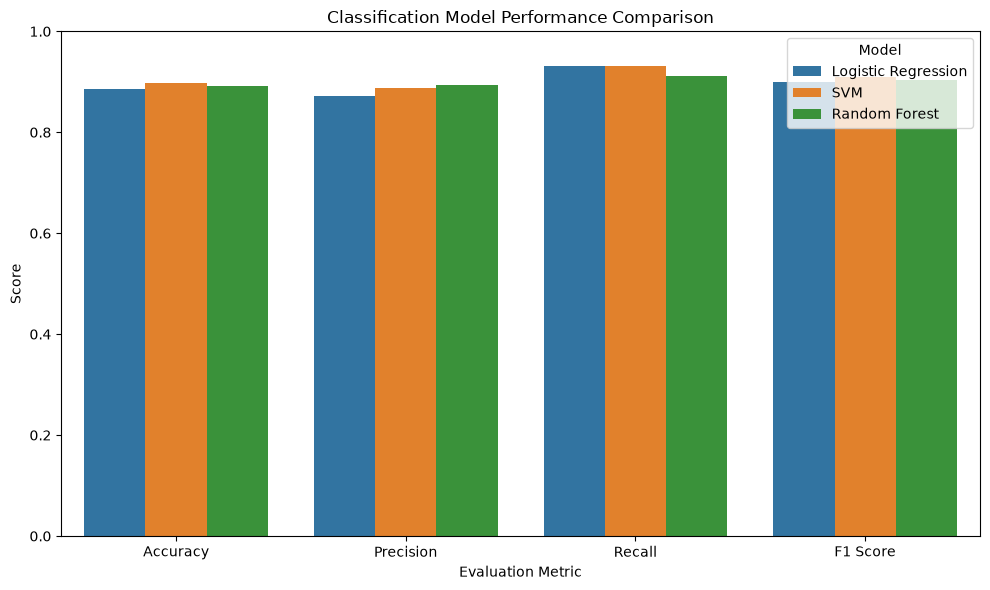

In [31]:

# Reshape the comparison table so it is easier to graph.
comparison_long = model_comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

# Create a grouped bar chart.
plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Score",
    hue="Model"
)

# Add titles and labels.
plt.title("Classification Model Performance Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

# Keep the y-axis between 0 and 1.
plt.ylim(0, 1)

plt.legend(title="Model")
plt.tight_layout()
plt.show()

In [32]:
# Import the ROC-AUC evaluation metric.
from sklearn.metrics import roc_auc_score

# Get the predicted probability of class 1
# for each patient in the test set.
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC.
logistic_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

print("Logistic Regression ROC-AUC:", round(logistic_auc, 3))

Logistic Regression ROC-AUC: 0.93


In [33]:
# Get the SVM decision scores for the test records.
svm_scores = svm_model.decision_function(X_test)

# Calculate ROC-AUC using the decision scores.
svm_auc = roc_auc_score(
    y_test,
    svm_scores
)

print("SVM ROC-AUC:", round(svm_auc, 3))

SVM ROC-AUC: 0.949


In [34]:
# Get the predicted probability of class 1
# for each test record.
random_forest_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC.
random_forest_auc = roc_auc_score(
    y_test,
    random_forest_probabilities
)

print("Random Forest ROC-AUC:", round(random_forest_auc, 3))

Random Forest ROC-AUC: 0.93


In [35]:
# Add ROC-AUC results to the existing comparison table.

model_comparison["ROC-AUC"] = [
    logistic_auc,
    svm_auc,
    random_forest_auc
]

# Round all values to three decimal places.
model_comparison = model_comparison.round(3)

# Bold the highest value in each metric.
styled_comparison = model_comparison.style.highlight_max(
    subset=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    props="font-weight: bold;"
)

display(styled_comparison)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.886000,0.872000,0.931000,0.900000,0.930000
1,SVM,0.897000,0.888000,0.931000,0.909000,0.949000
2,Random Forest,0.891000,0.894000,0.912000,0.903000,0.930000


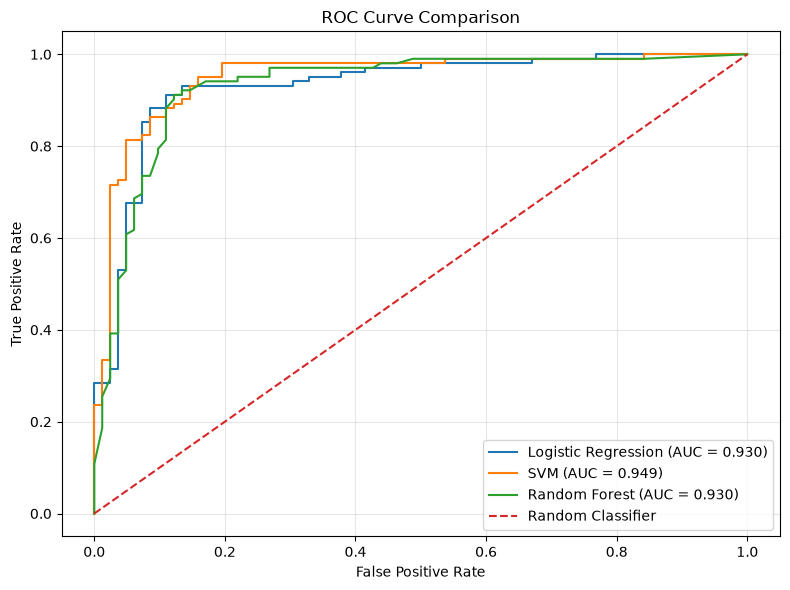

In [36]:
# ============================================================
# ROC CURVE COMPARISON
# ============================================================

from sklearn.metrics import roc_curve

# Calculate ROC curve values for Logistic Regression.
log_fpr, log_tpr, _ = roc_curve(
    y_test,
    logistic_probabilities
)

# Calculate ROC curve values for SVM.
svm_fpr, svm_tpr, _ = roc_curve(
    y_test,
    svm_scores
)

# Calculate ROC curve values for Random Forest.
rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    random_forest_probabilities
)

# Create the ROC curve graph.
plt.figure(figsize=(8, 6))

plt.plot(
    log_fpr,
    log_tpr,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    svm_fpr,
    svm_tpr,
    label=f"SVM (AUC = {svm_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {random_forest_auc:.3f})"
)

# Add the random-classification reference line.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()